### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [4]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Import Dataset

In [5]:
df = pd.read_csv('./data/bitcoin.csv')

In [6]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [7]:
df.shape

(2713, 7)

In [8]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555057,11323.914637,11323.914637,1.470462e+10
std,16106.428891,16537.390649,15608.572560,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399414,10762.644531,10202.387695,10462.259766,10462.259766,2.456992e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   object 
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 148.5+ KB


### Step 3: Exploratory Data Analysis

Text(0, 0.5, 'Price in dollars')

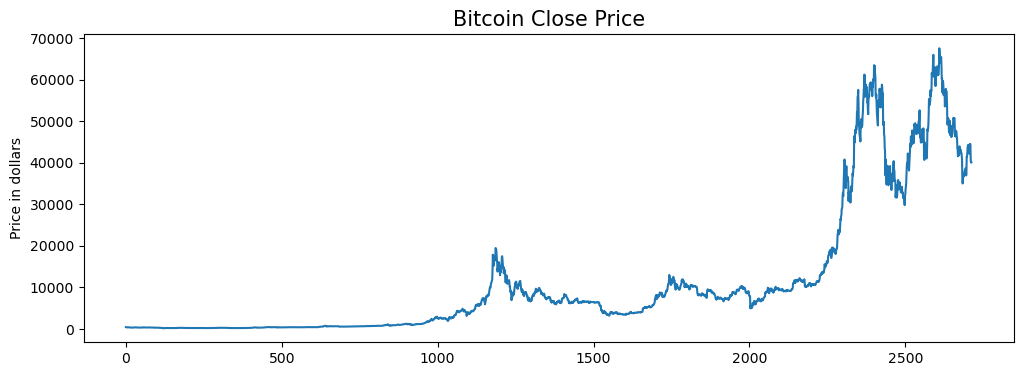

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(df['Close'])
plt.title('Bitcoin Close Price', fontsize=15)
plt.ylabel('Price in dollars')

In [14]:
df = df.drop(['Adj Close'], axis=1)

In [15]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

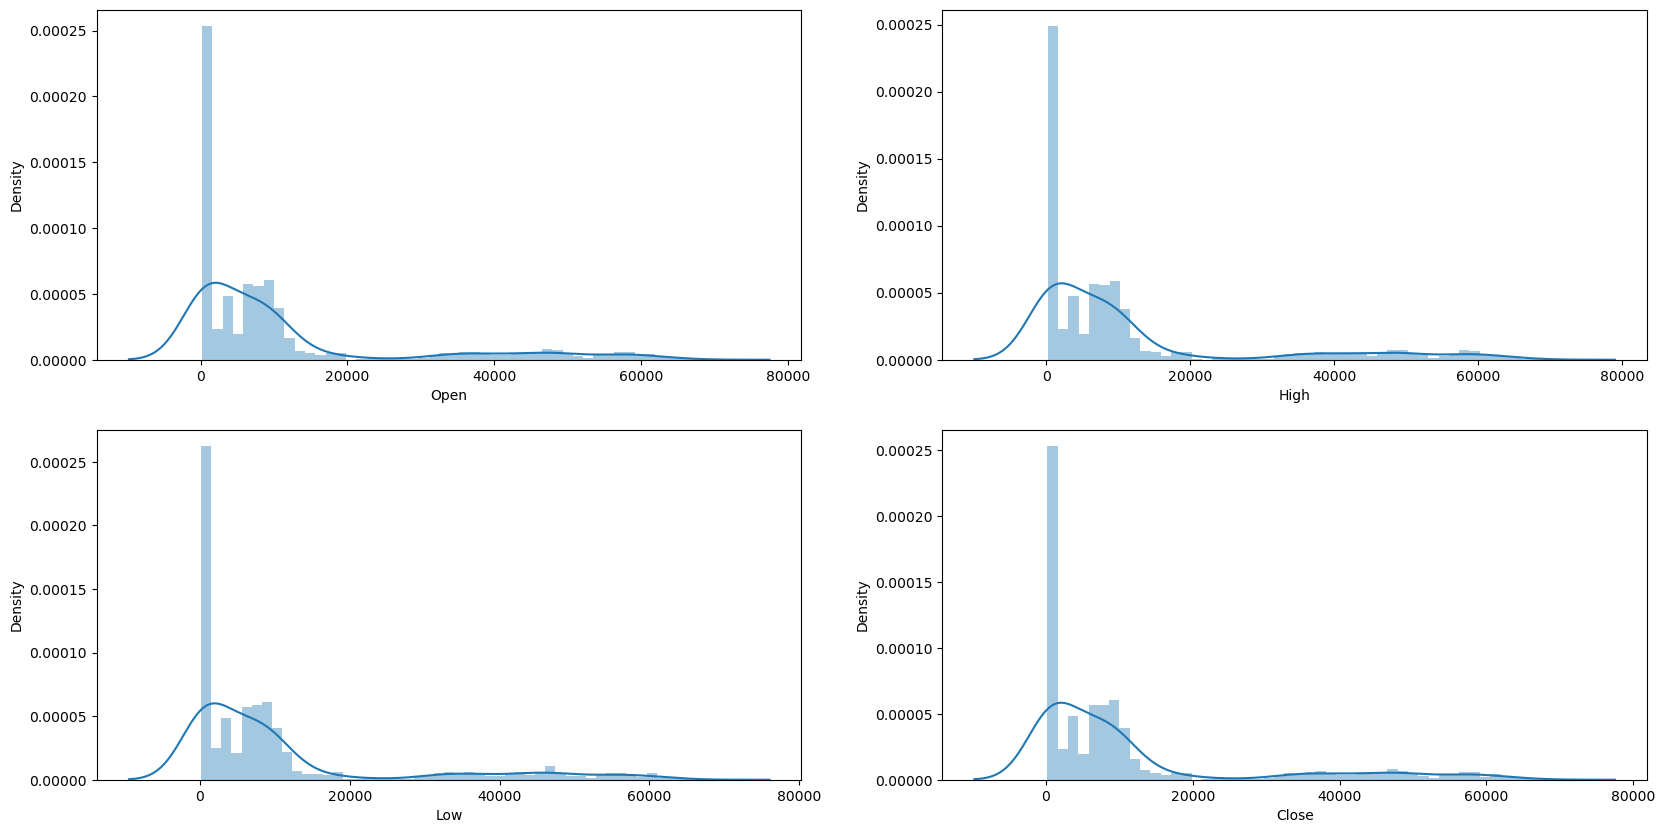

In [24]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
for i, col in enumerate(df.columns[1:-1]):
    sns.distplot(df[col], ax=ax[i//2][i%2])

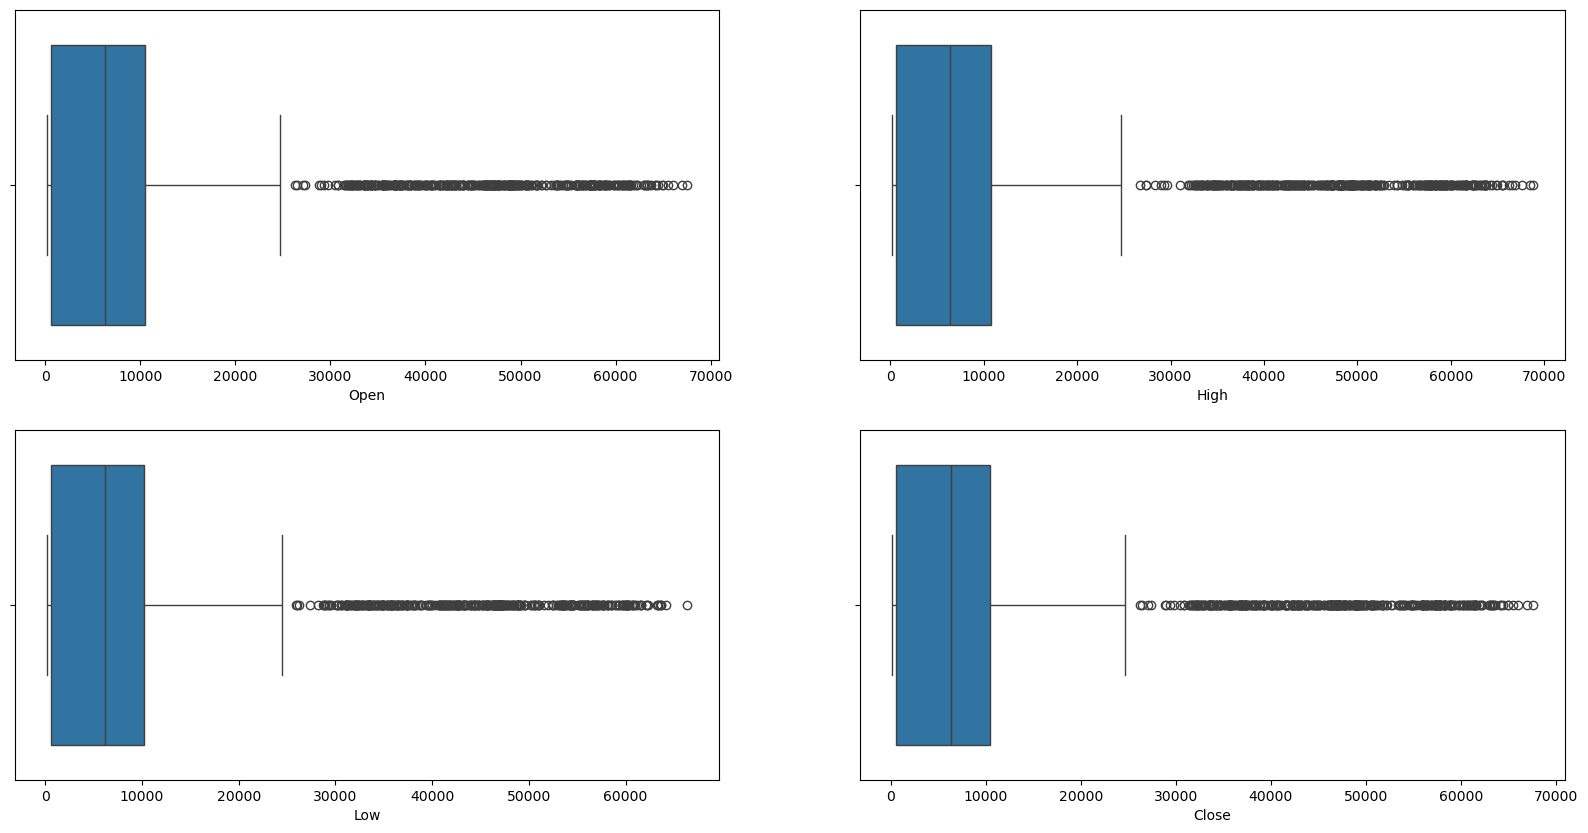

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
for i, col in enumerate(df.columns[1:-1]):
    sns.boxplot(df[col], orient='h', ax=ax[i//2][i%2])

### Step 4: Feature Engineering

In [28]:
splitted = df['Date'].str.split('-', expand=True)

In [29]:
df['year'] = splitted[0].astype(np.int16)
df['month'] = splitted[1].astype(np.int16)
df['day'] = splitted[2].astype(np.int16)

In [31]:
df['Date'] = pd.to_datetime(df['Date'])

In [32]:
df.head()

,Date,Open,High,Low,Close,Volume,year,month,day
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21


In [33]:
data_grouped = df.groupby('year').mean()

In [39]:
data_grouped

,Date,Open,High,Low,Close,Volume,month,day
year,,,,,,,,
2014,2014-11-08 12:00:00,365.058217,373.265397,355.903726,363.693085,2.383690e+07,10.735849,16.849057
2015,2015-07-02 00:00:00,272.149011,278.151978,266.807891,272.453381,3.390557e+07,6.526027,15.720548
2016,2016-07-01 12:00:00,567.141429,574.302273,560.453374,568.492407,8.592451e+07,6.513661,15.756831
2017,2017-07-02 00:00:00,3970.644848,4144.687445,3811.707792,4006.033629,2.382867e+09,6.526027,15.720548
2018,2018-07-02 00:00:00,7601.018680,7787.978969,7350.747939,7572.298947,6.063552e+09,6.526027,15.720548
2019,2019-07-02 00:00:00,7385.218456,7549.907409,7222.602868,7395.246282,1.673049e+10,6.526027,15.720548
2020,2020-07-01 12:00:00,11056.787201,11304.359035,10844.595163,11116.378092,3.302327e+10,6.513661,15.756831
2021,2021-07-02 00:00:00,47402.115663,48762.998925,45852.003082,47436.932021,4.715574e+10,6.526027,15.720548
2022,2022-01-25 12:00:00,41468.636797,42225.196172,40415.898360,41345.687735,2.718684e+10,1.380000,13.720000


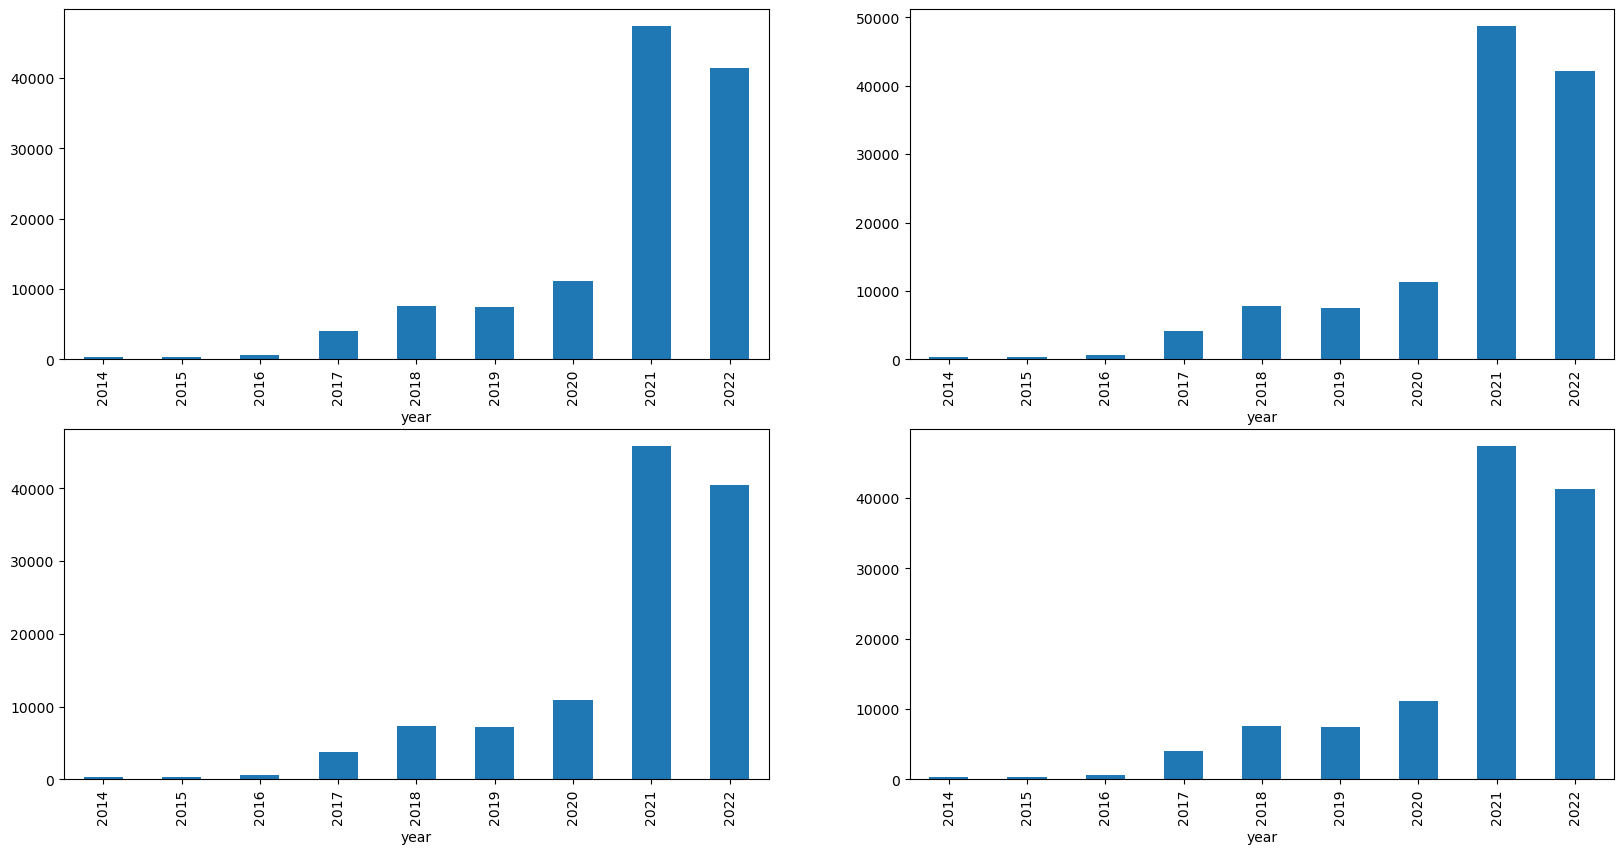

In [37]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
for i, col in enumerate(data_grouped.columns[1:5]):
    data_grouped[col].plot.bar(ax=ax[i//2][i%2])

In [40]:
df['is_quarter_end'] = np.where(df['month'] % 3 == 0, 1, 0)

In [41]:
df.head()

,Date,Open,High,Low,Close,Volume,year,month,day,is_quarter_end
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,1
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,1
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,1
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,1
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,1


In [42]:
df['open-close'] = df['Open'] - df['Close']
df['high-low'] = df['High'] - df['Low']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

In [43]:
df.head()

,Date,Open,High,Low,Close,Volume,year,month,day,is_quarter_end,open-close,high-low,target
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,1,8.529999,15.752014,0
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,1,32.419983,43.755981,0
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,1,29.307007,43.302978,1
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,1,-14.230988,33.412994,0
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,1,9.263977,19.244995,1


In [46]:
df['target'].value_counts().values

array([1469, 1244], dtype=int64)

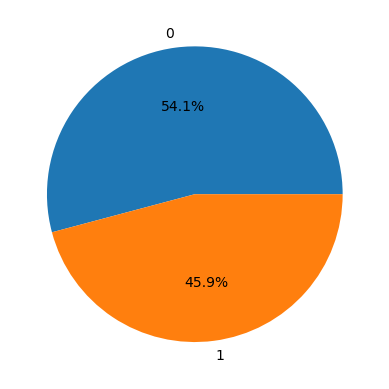

In [48]:
_ = plt.pie(df['target'].value_counts().values, labels=[0, 1], autopct='%1.1f%%')

<Axes: >

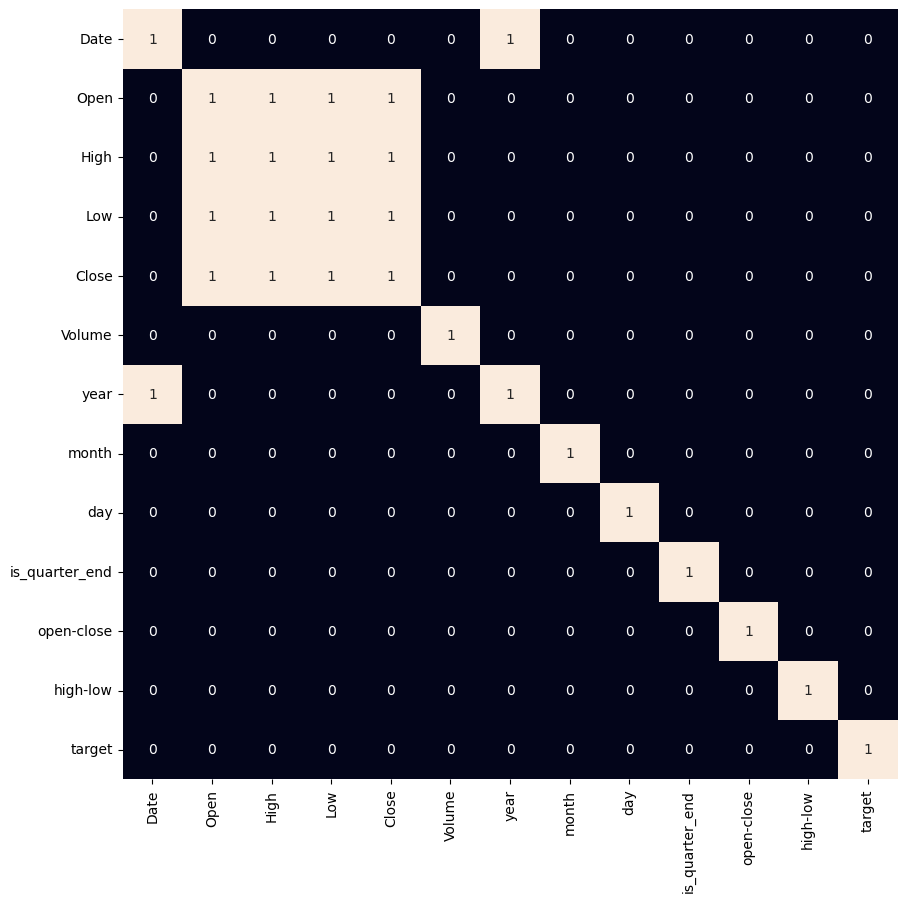

In [49]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr() > 0.9, annot=True, cbar=False)

In [50]:
features = df[['open-close', 'high-low', 'is_quarter_end']]
target = df['target']

In [51]:
scaler = StandardScaler()

In [52]:
features = scaler.fit_transform(features)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.3,
    random_state=42
)

### Step 5: Model Development and Evaluation

In [56]:
models = [LogisticRegression(), SVC(kernel='poly', probability=True), XGBClassifier()]

In [58]:
for model in models:
    model.fit(X_train, y_train)
    print(f'{model} : ')
    print('Training Accuracy : ', metrics.roc_auc_score(y_train, model.predict_proba(X_train)[:,1]))
    print('Validation Accuracy : ', metrics.roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))
    print('----------')

LogisticRegression() : 
Training Accuracy :  0.5319642853158836
Validation Accuracy :  0.5117827868852459
----------
SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.4656038677521479
Validation Accuracy :  0.4712321916471507
----------
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=

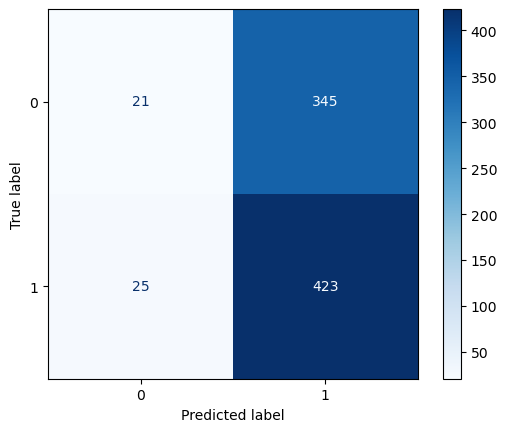

In [61]:
metrics.ConfusionMatrixDisplay.from_estimator(models[0], X_test, y_test, cmap=plt.cm.Blues)

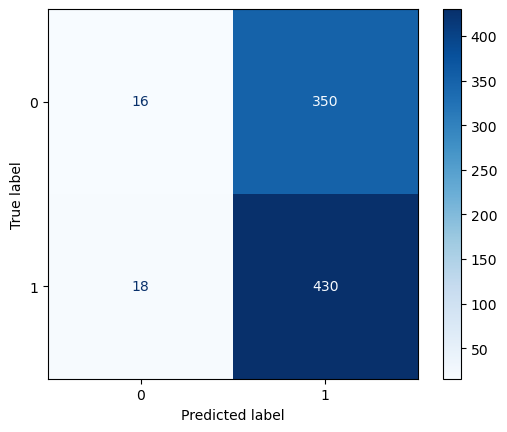

In [62]:
metrics.ConfusionMatrixDisplay.from_estimator(models[1], X_test, y_test, cmap=plt.cm.Blues)

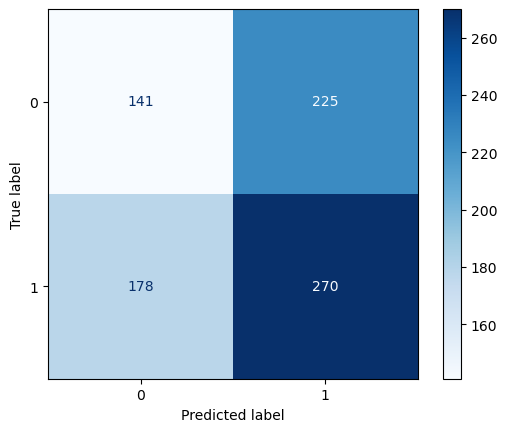

In [63]:
metrics.ConfusionMatrixDisplay.from_estimator(models[2], X_test, y_test, cmap=plt.cm.Blues)